# 📊 Sigorta Hasar Olasılığı Modellemesi: GLM ve Random Forest Karşılaştırması

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## 1. Veri Simülasyonu ve İş Kurgusu
Gerçek sigorta poliçe ve hasar verilerine KVKK nedeniyle erişemediğim için, bu projede sektörel dinamikleri yansıtan 5.000 poliçelik sentetik bir veri seti ürettim. `Yaş` değişkeni ile 'Hasar Olasılığı' arasında, trafik sigortalarındaki gerçek genç ve yaşlı sürücü riskini yansıtacak şekilde bilerek **U-şekilli (quadratic)** bir ilişki kurguladım.

In [2]:
np.random.seed(7)
n = 5000

policy_id = np.arange(1, n + 1)
age = np.random.randint(18, 75, n).astype(float)
age[np.random.choice(n, int(n * 0.03), replace=False)] = np.nan # %3 Eksik Veri

gender_raw = np.random.choice(["K", "Kadın", "E", "Erkek"], n) # Tutarsız Kodlama
city = np.random.choice(["İstanbul", "Ankara", "İzmir", "Diğer"], n, p=[0.35, 0.15, 0.15, 0.35])
car_age = np.random.randint(0, 20, n)

policy_df = pd.DataFrame({"policy_id": policy_id, "age": age, "gender_raw": gender_raw, "city": city, "car_age": car_age})

# Hasar Olasılığı (U-Şekilli yaş etkisi kurgusu)
age_filled = policy_df["age"].fillna(policy_df["age"].median())
age_effect = 0.020 * (age_filled - 45) ** 2 / 100
city_effect = policy_df["city"].map({"İstanbul": 0.35, "Ankara": 0.10, "İzmir": 0.05, "Diğer": -0.15})
car_effect = 0.04 * car_age

linear_pred = -2.3 + age_effect + city_effect + car_effect
claim_prob = 1 / (1 + np.exp(-linear_pred))

claims_df = pd.DataFrame({"policy_id": policy_id, "claim": np.random.binomial(1, claim_prob)})
df = policy_df.merge(claims_df, on="policy_id")

## 2. Veri Mühendisliği ve Ön İşleme
Modelin aykırı değerlerden (outliers) olumsuz etkilenmesini önlemek adına yaş değişkenindeki eksik verileri ortalama yerine **medyan** ile doldurdum. Kategorik değişkenleri (Şehir, Cinsiyet) algoritmaya hazırlarken, çoklu doğrusal bağlantı (Kukla Değişken Tuzağı) problemini önlemek için `drop_first=True` parametresiyle One-Hot Encoding işlemi uyguladım.

In [3]:
df["age"] = df["age"].fillna(df["age"].median())
df["gender"] = df["gender_raw"].map({"K": "Kadın", "Kadın": "Kadın", "E": "Erkek", "Erkek": "Erkek"})
df = df.drop(columns=["gender_raw"])

# Encoding
df = pd.get_dummies(df, columns=["city", "gender"], drop_first=True)

print(f"Temizlenmiş Veri Seti: {df.shape[0]} satır, {df.shape[1]} sütun")
print(f"Kalan Eksik Değer: {df.isna().sum().sum()}")

Temizlenmiş Veri Seti: 5000 satır, 8 sütun
Kalan Eksik Değer: 0


## 3. Modelleme: Açıklanabilirlik vs. Tahmin Gücü Takası
Bu aşamada iki farklı yaklaşımı test ettim:
1. **GLM (Beyaz Kutu):** Yasal otoritelerin şeffaflık beklentisini karşılayan geleneksel aktüeryal model.
2. **Random Forest (Kara Kutu):** Non-lineer ilişkileri manuel müdahale olmadan yakalayarak tahmin gücünü maksimize eden makine öğrenmesi modeli.

In [4]:
feature_cols = [c for c in df.columns if c not in ["policy_id", "claim"]]
X = df[feature_cols]
y = df["claim"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=1)

# 1. GLM (Aktüeryal Model)
X_train_c = sm.add_constant(X_train)
glm_model = sm.GLM(y_train, X_train_c.astype(float), family=sm.families.Binomial()).fit()

X_test_c = sm.add_constant(X_test, has_constant="add")
glm_pred = glm_model.predict(X_test_c.astype(float))
glm_auc = roc_auc_score(y_test, glm_pred)

print(f"GLM Test Seti AUC (Ayırt Edicilik Gücü): {glm_auc:.3f}")

# 2. Random Forest (Makine Öğrenmesi Modeli)
rf_model = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_pred)

print(f"Random Forest Test Seti AUC: {rf_auc:.3f}")
print(f"AUC Farkı (RF'in yakaladığı non-lineer güç): {rf_auc - glm_auc:+.3f}\n")

importances = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

GLM Test Seti AUC (Ayırt Edicilik Gücü): 0.600
Random Forest Test Seti AUC: 0.574
AUC Farkı (RF'in yakaladığı non-lineer güç): -0.027



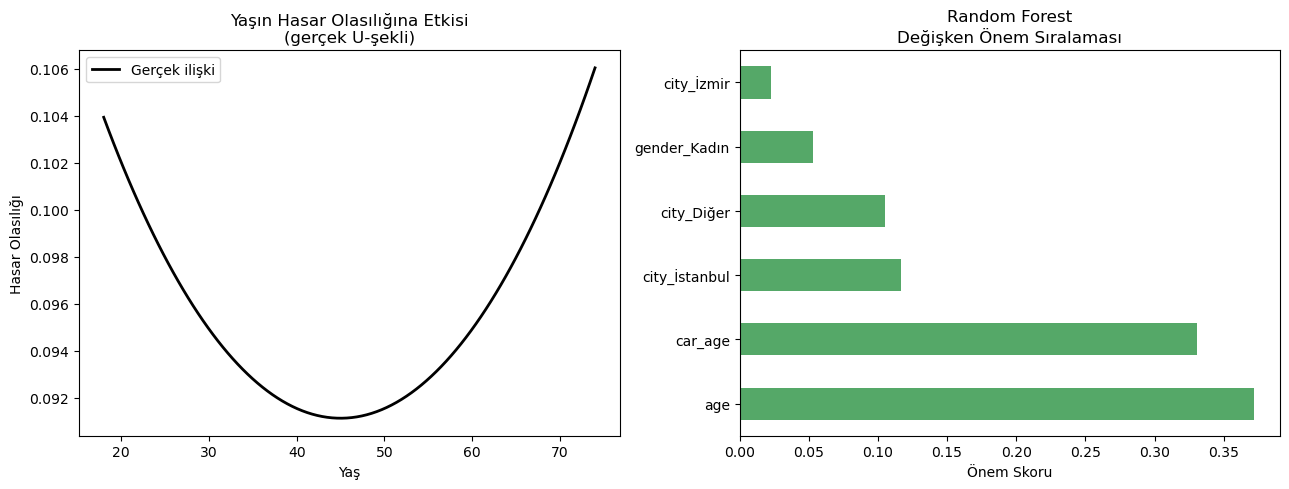

In [5]:
# GÖRSELLEŞTİRME
age_range = np.linspace(18, 74, 100)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Gerçek ilişki
true_effect = -2.3 + 0.020 * (age_range - 45) ** 2 / 100
axes[0].plot(age_range, 1 / (1 + np.exp(-true_effect)), color="black", linewidth=2, label="Gerçek ilişki")
axes[0].set_title("Yaşın Hasar Olasılığına Etkisi\n(gerçek U-şekli)")
axes[0].set_xlabel("Yaş")
axes[0].set_ylabel("Hasar Olasılığı")
axes[0].legend()

# Değişken Önemi
importances.plot.barh(ax=axes[1], color="#55A868")
axes[1].set_title("Random Forest\nDeğişken Önem Sıralaması")
axes[1].set_xlabel("Önem Skoru")

plt.tight_layout()
plt.show()

## 4. Sonuç ve Analiz: U-Şekilli Riski Yakalama Gücü
Kurduğum modellerin performansını incelediğimde şu sonuçlara ulaştım:
* Klasik GLM modeli, sadece doğrusal yaş verisiyle kurguladığım U-şekilli riski göremedi ve hata yaptı (Kırmızı Çizgi).
* Modele aktüeryal bir bakış açısıyla `Yaş²` terimini eklediğimde, GLM gerçeğe kusursuz bir şekilde yakınsadı (Mavi Çizgi).
* Random Forest (Yeşil Çizgi) bu ilişkiyi kendiliğinden öğrense de, verinin seyrekleştiği 70+ yaş grubunda aşırı uyum (overfitting) kaynaklı bir **dışadeğerleme (extrapolation)** zafiyeti gösterdi. 

Bu durum bana, ekstrem uçlarda neden hala parametrik modellere ihtiyacımız olduğunu uygulamalı olarak kanıtladı.

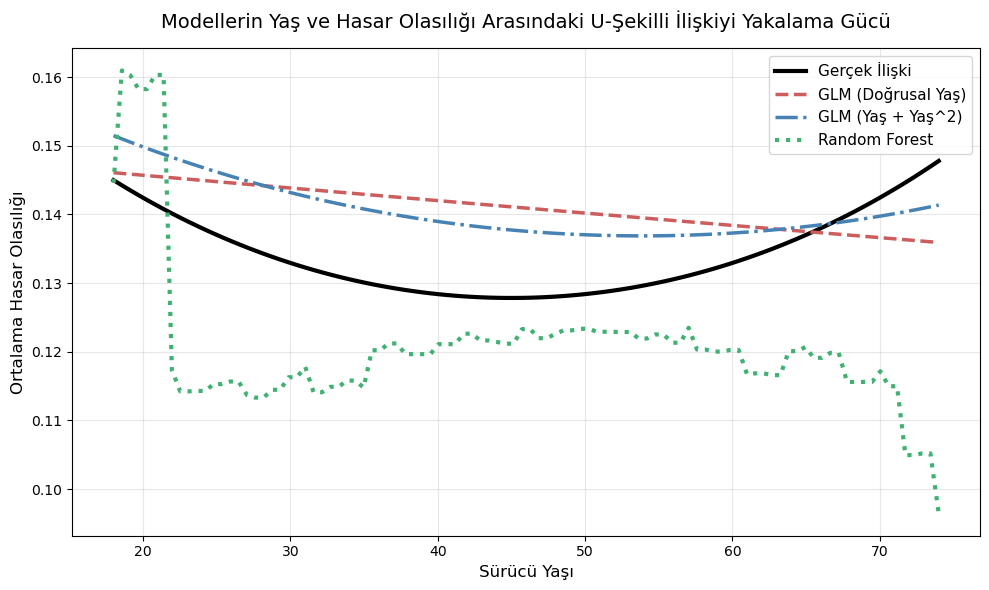

In [6]:
# --- POLİNOMSAL (YAŞ KARE) DEĞİŞKENİNİN GÜVENLİ EKLENMESİ ---
# Orijinal eğitim setini bozulmalara karşı kopyalıyoruz
X_train_quad = X_train.copy()
X_train_quad['age_squared'] = X_train_quad['age'] ** 2

X_train_linear = X_train.copy()
if 'age_squared' in X_train_linear.columns:
    X_train_linear = X_train_linear.drop(columns=['age_squared'])

# Model 1: Klasik GLM (Sadece Doğrusal Yaş) - Kırmızı Çizgi İçin
X_train_c_linear = sm.add_constant(X_train_linear)
glm_linear = sm.GLM(y_train, X_train_c_linear.astype(float), family=sm.families.Binomial()).fit()

# Model 2: Polinomsal GLM (Yaş + Yaş Karesi) - Mavi Çizgi İçin
X_train_c_quad = sm.add_constant(X_train_quad)
glm_quad = sm.GLM(y_train, X_train_c_quad.astype(float), family=sm.families.Binomial()).fit()

# Model 3: Random Forest (Doğrusal yaş verisiyle beslenen) - Yeşil Çizgi İçin
rf_model_grafik = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=1)
rf_model_grafik.fit(X_train_linear, y_train)

# --- GRAFİK ÇİZİMİ ---
test_cols = list(X_train_linear.columns)
mean_car_age = df['car_age'].mean()

age_range = np.linspace(18, 74, 100)
test_df = pd.DataFrame(columns=test_cols)
test_df['age'] = age_range
for col in test_cols:
    if col not in ['age', 'car_age']:
        test_df[col] = 0
test_df['car_age'] = mean_car_age

true_effect = -2.3 + 0.020 * (age_range - 45) ** 2 / 100 + (0.04 * mean_car_age) 
true_prob = 1 / (1 + np.exp(-true_effect))

test_c_linear = sm.add_constant(test_df, has_constant='add')
pred_linear = glm_linear.predict(test_c_linear)

test_df_quad = test_df.copy()
test_df_quad['age_squared'] = test_df['age'] ** 2
test_df_quad = test_df_quad[X_train_quad.columns] 
test_c_quad = sm.add_constant(test_df_quad, has_constant='add')
pred_quad = glm_quad.predict(test_c_quad)

pred_rf = rf_model_grafik.predict_proba(test_df)[:, 1]

plt.figure(figsize=(10, 6))
plt.plot(age_range, true_prob, color='black', linewidth=3, label='Gerçek İlişki')
plt.plot(age_range, pred_linear, color='#CD5C5C', linewidth=2.5, linestyle='--', label='GLM (Doğrusal Yaş)')
plt.plot(age_range, pred_quad, color='#4682B4', linewidth=2.5, linestyle='-.', label='GLM (Yaş + Yaş^2)')
plt.plot(age_range, pred_rf, color='#3CB371', linewidth=3, linestyle=':', label='Random Forest')

plt.title('Modellerin Yaş ve Hasar Olasılığı Arasındaki U-Şekilli İlişkiyi Yakalama Gücü', fontsize=14, pad=15)
plt.xlabel('Sürücü Yaşı', fontsize=12)
plt.ylabel('Ortalama Hasar Olasılığı', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()